# HomeWork3 Дуркин Макар

In [79]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math
import copy

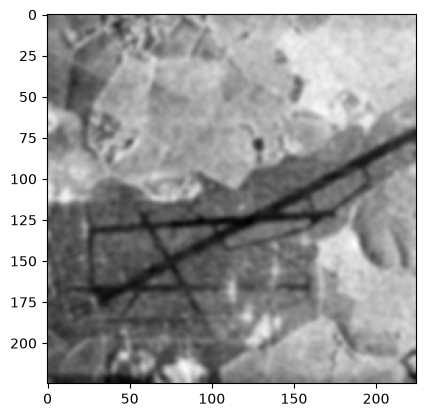

In [36]:
image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Удаление шума
image_gray = cv2.GaussianBlur(image_gray, (7, 7), 0)

plt.imshow(image_gray, cmap="gray")

## 1. Поиск наиболее протяженного участка с помощью преобразования Хафа

### Детектор границ Кэнни

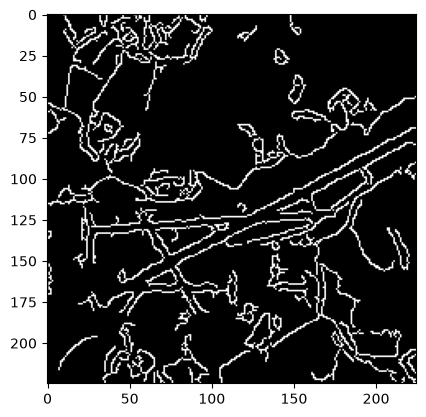

In [37]:
canny = cv2.Canny(image_gray, 50, 150, apertureSize=3)

plt.imshow(canny, cmap="gray")

### Преобразование Хафа

Наиболее протяжённый участок: (19, 176) -> (221, 69), длина = 228.59 пикселей


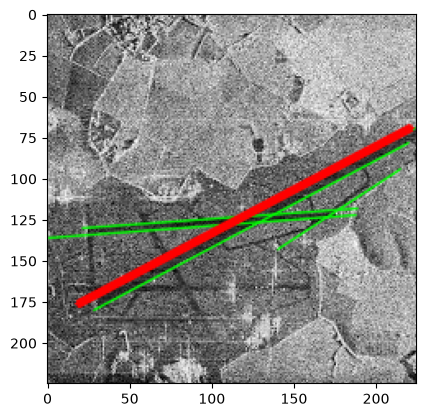

In [77]:
lines = cv2.HoughLinesP(canny, 1, np.pi / 180, 70, minLineLength=20, maxLineGap=23)
# Порог длины - 70, минимальная длина, которая учитывается - 20, максимальный разрыв - 23
# Такие параметры дали более точный результат

image_draw = image.copy()

longest_line = None
max_length = 0

for i in range(0, len(lines)):
    x1, y1, x2, y2 = lines[i][0]

    length = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

    if length > max_length:
        max_length = length
        longest_line = (x1, y1, x2, y2)

    cv2.line(image_draw, (x1, y1), (x2, y2), (0, 255, 0), 1, cv2.LINE_AA)

x1, y1, x2, y2 = longest_line
cv2.line(image_draw, (x1, y1), (x2, y2), (0, 0, 255), 3, cv2.LINE_AA)
print(f"Наиболее протяжённый участок: ({x1}, {y1}) -> ({x2}, {y2}), длина = {max_length:.2f} пикселей")

plt.imshow(cv2.cvtColor(image_draw, cv2.COLOR_BGR2RGB))

## 2. Выделение участка полосы с помощью алгоритмов бинаризации

### Точечная бинаризация

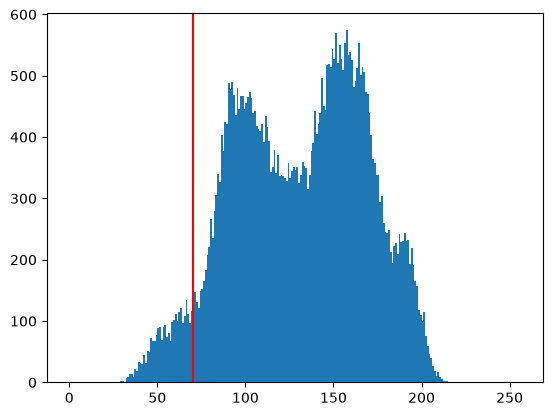

In [105]:
bin_img = copy.deepcopy(image_gray)
T  = 70
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255
plt.hist(image_gray.ravel(), bins=256, range=(0, 256))
plt.axvline(T, color='r')
plt.show()

### Бинаризация Отсу

In [81]:
_,th2 = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

### Адаптивная бинаризация

In [153]:
th3 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,301,41)

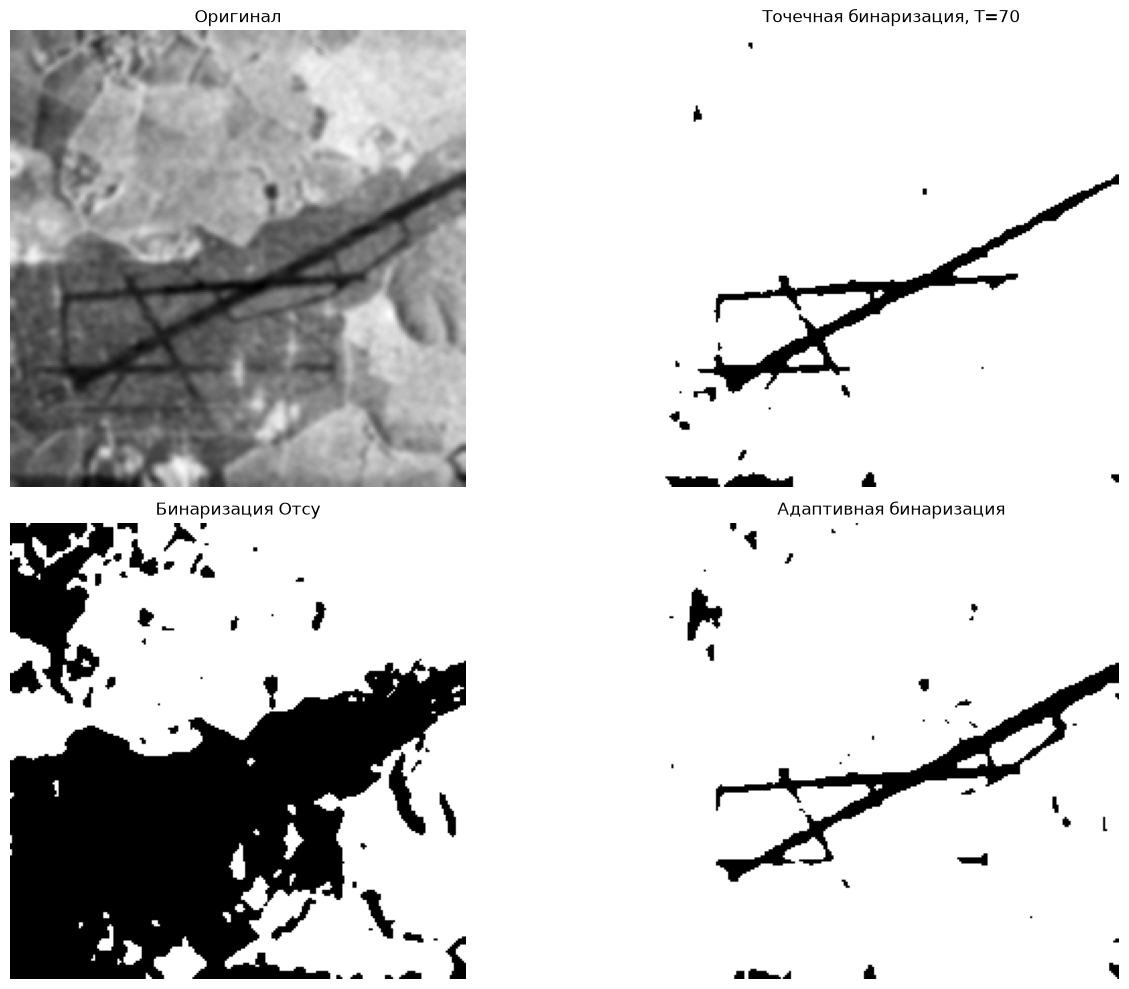

In [156]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(image_gray, cmap="gray")
plt.title("Оригинал")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(bin_img, cmap="gray")
plt.title(f"Точечная бинаризация, T={T}")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(th2, cmap="gray")
plt.title("Бинаризация Отсу")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(th3, cmap="gray")
plt.title("Адаптивная бинаризация")
plt.axis('off')

plt.tight_layout()
plt.show()

Поигравшись с параметрами, пришел к выводу, что более точный участок дороги выделяют алгоритмы точечной бинаризации и адаптивной бинаризации с параметрами 70 и 301, 41 соответственно. Бинаризация Отсу с нахождением участка дороги, можно сказать, что не справилась